<a href="https://colab.research.google.com/github/caystreet/lawyer_disclaimer_template/blob/main/momomodelv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fetching ETF data:  92%|█████████▏| 34/37 [00:14<00:00,  3.04it/s]

Error fetching data for BTC-USD: 404


Fetching ETF data: 100%|██████████| 37/37 [00:15<00:00,  2.34it/s]
/tmp/ipython-input-4112048561.py:81: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  monthly_prices = prices.resample('BM').last()


Output View as of 2025-11-28 (Business Month-End):
      Return_1M  Return_3M  Return_9M  Volatility_12M  Correlation_SPY_30D  \
GDX    0.144109   0.275778   0.739753        0.098425             0.688320   
IBB    0.086787   0.229231   0.237878        0.056082             0.532257   
IEF    0.006689   0.013943   0.022613        0.014225            -0.058574   
XLV    0.088829   0.137263   0.056901        0.049959             0.339698   
TLT   -0.000886   0.040840  -0.024311        0.032535             0.066432   
XLP    0.039710  -0.017609  -0.045684        0.030456             0.010138   
KIE    0.062219   0.019349  -0.000999        0.048414             0.116465   
TIP   -0.001078   0.000809   0.008303        0.011532             0.104927   
PBW   -0.057106   0.224725   0.589115        0.104906             0.818886   
XME    0.005163   0.164903   0.513473        0.087881             0.777557   
TAN   -0.004284   0.163084   0.413368        0.081054             0.722988   
AMLP   0.0216

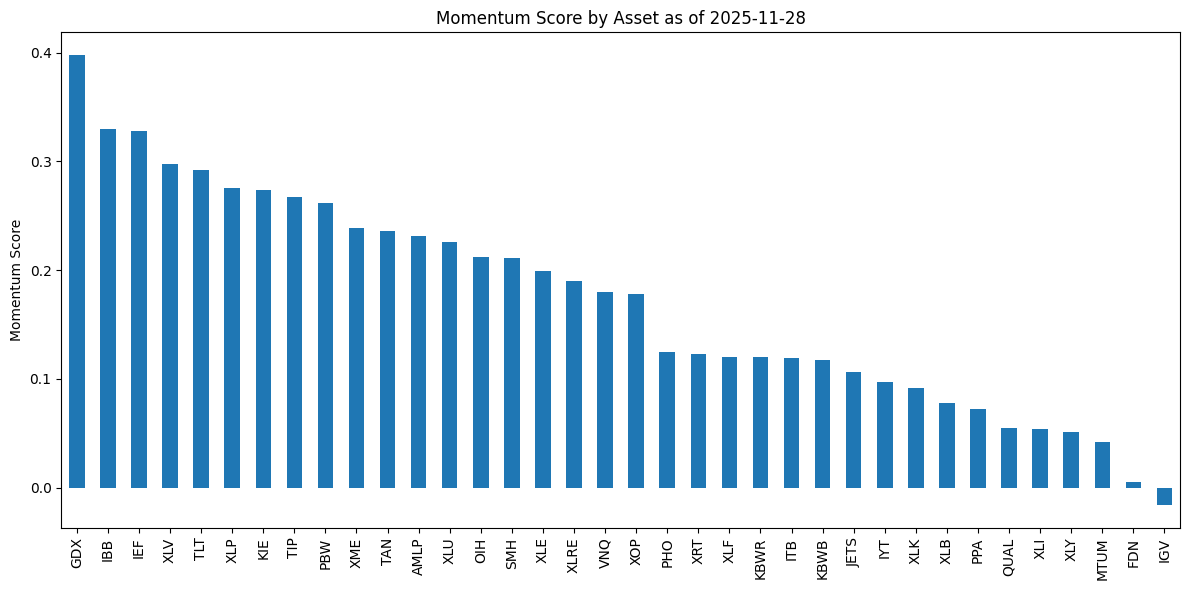

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm

# ----------------------------
# Helper Function: Fetch Data from Tiingo
# ----------------------------
def get_tiingo_data(ticker, start_date, end_date, api_key):
    """
    Fetch daily end-of-day data for a given ticker from Tiingo.
    Returns a DataFrame with the 'close' prices, indexed by date.
    """
    url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
    params = {
        'startDate': start_date.strftime('%Y-%m-%d'),
        'endDate': end_date.strftime('%Y-%m-%d'),
        'token': api_key
    }
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Error fetching data for {ticker}: {response.status_code}")
        return None
    data = response.json()
    if not data:
        print(f"No data returned for {ticker}")
        return None
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    # Use the 'close' price and rename the column to the ticker symbol.
    df = df[['close']].rename(columns={'close': ticker})
    return df

# ----------------------------
# Parameters and Tickers
# ----------------------------
TIINGO_API_KEY = "e30bc8b0b855970d930743b116e517e36b72cc8f"  # Replace with your Tiingo API key

# List of ETFs and assets (BTC, TLT, IEF, TIP treated like ETFs)
etfs = ["XLE", "XLF", "XLK", "XLB", "XLRE", "XLU", "XLV", "XLP",
        "XLY", "XLI", "MTUM", "QUAL", "KBWR", "KBWB", "XME",
        "VNQ", "GDX", "AMLP", "ITB", "OIH", "XRT", "FDN", "IBB",
        "SMH", "XOP", "PBW", "KIE", "PHO", "IGV", "TAN",
        "JETS", "IYT", "PPA", "BTC-USD", "TLT", "IEF", "TIP"]

# Benchmark ticker (SPY)
benchmark_ticker = "SPY"

# Define the date range: 10 years ending December 31, 2024
end_date = datetime(2025, 11, 30)
start_date = end_date - timedelta(days=365*10)

# ----------------------------
# Data Retrieval: Fetch ETF/Asset Data from Tiingo
# ----------------------------
data = {}
for etf in tqdm(etfs, desc="Fetching ETF data"):
    df = get_tiingo_data(etf, start_date, end_date, TIINGO_API_KEY)
    if df is not None:
        data[etf] = df

if not data:
    raise ValueError("No ETF data available. Please check your API key or ticker list.")

prices = pd.concat(data.values(), axis=1).ffill()

# ----------------------------
# Data Retrieval: Fetch Benchmark Data (SPY) from Tiingo
# ----------------------------
spy_data = get_tiingo_data(benchmark_ticker, start_date, end_date, TIINGO_API_KEY)
if spy_data is None:
    raise ValueError("No benchmark data available. Please check your API key or ticker.")

# ----------------------------
# Compute Monthly Data and Momentum Factors
# ----------------------------
# Use business month-end ('BM') to ensure we get the last trading day.
monthly_prices = prices.resample('BM').last()
monthly_returns = np.log(monthly_prices).diff().dropna()

# Compute momentum factors from monthly returns:
# r1m: 1-month return; r3m: 3-month cumulative; r9m: 9-month cumulative
r1m = monthly_returns.copy()
r3m = monthly_returns.rolling(window=3, min_periods=3).sum()
r9m = monthly_returns.rolling(window=9, min_periods=9).sum()

# 12-month rolling volatility (from monthly returns)
vol = monthly_returns.rolling(window=12, min_periods=12).std()

# ----------------------------
# Compute Daily Returns for Rolling Correlation/Covariance with SPY
# ----------------------------
daily_returns = np.log(prices).diff().dropna()
daily_spy = np.log(spy_data).diff().dropna()[benchmark_ticker]

# ----------------------------
# Define New Weights for Momentum Score:
# 3m weighted at 65% and 1m and 9m each at 17.5%
w1m, w3m, w9m = 0.175, 0.65, 0.175
beta, gamma = 0.3, 0.3  # Penalty for volatility and adjustment for correlation

# ----------------------------
# Select a Rebalancing Date for Output View
# ----------------------------
# For this output view, we will choose the latest business month-end date from our monthly data.
latest_date = monthly_prices.index[-1]

# Compute daily correlation and covariance with SPY using the 30-day window ending at latest_date.
start_corr = latest_date - pd.Timedelta(days=30)
window_daily = daily_returns.loc[start_corr:latest_date]
window_spy = daily_spy.loc[start_corr:latest_date]

corr_scores = {}
cov_scores = {}
for asset in monthly_returns.columns:
    if asset in window_daily.columns:
        corr_scores[asset] = window_daily[asset].corr(window_spy)
        cov_scores[asset] = window_daily[asset].cov(window_spy)
    else:
        corr_scores[asset] = np.nan
        cov_scores[asset] = np.nan
corr_series = pd.Series(corr_scores)
cov_series = pd.Series(cov_scores)

# Compute the momentum score at the latest_date for each asset.
momentum_score = (w1m * r1m.loc[latest_date] +
                  w3m * r3m.loc[latest_date] +
                  w9m * r9m.loc[latest_date] -
                  beta * vol.loc[latest_date] +
                  gamma * (1 - corr_series))

# Combine all outputs into a DataFrame for view.
output_view = pd.DataFrame({
    "Return_1M": r1m.loc[latest_date],
    "Return_3M": r3m.loc[latest_date],
    "Return_9M": r9m.loc[latest_date],
    "Volatility_12M": vol.loc[latest_date],
    "Correlation_SPY_30D": corr_series,
    "Covariance_SPY_30D": cov_series,
    "Momentum_Score": momentum_score
})

print("Output View as of {} (Business Month-End):".format(latest_date.date()))
print(output_view.sort_values(by="Momentum_Score", ascending=False))

# Optionally, plot the momentum score for visual inspection.
plt.figure(figsize=(12, 6))
output_view["Momentum_Score"].sort_values(ascending=False).plot(kind="bar")
plt.title("Momentum Score by Asset as of {}".format(latest_date.date()))
plt.ylabel("Momentum Score")
plt.tight_layout()
plt.show()


w/ portfolio

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm
import time # Import the time module

# ----------------------------
# Helper Function: Fetch Data from Tiingo
# ----------------------------
def get_tiingo_data(ticker, start_date, end_date, api_key):
    """
    Fetch daily end-of-day data for a given ticker from Tiingo.
    Returns a DataFrame with the 'close' prices, indexed by date.
    """
    url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
    params = {
        'startDate': start_date.strftime('%Y-%m-%d'),
        'endDate': end_date.strftime('%Y-%m-%d'),
        'token': api_key
    }
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Error fetching data for {ticker}: {response.status_code}")
        return None
    data = response.json()
    if not data:
        print(f"No data returned for {ticker}")
        return None
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    # Use the 'close' price and rename the column to the ticker symbol.
    df = df[['close']].rename(columns={'close': ticker})
    return df

# ----------------------------
# Parameters and Tickers
# ----------------------------
TIINGO_API_KEY = "e30bc8b0b855970d930743b116e517e36b72cc8f"  # Your provided API key

# List of ETFs and assets (BTC, TLT, IEF, TIP treated like ETFs)
etfs = ["XLE", "XLF", "XLK", "XLB", "XLRE", "XLU", "XLV", "XLP",
        "XLY", "XLI", "MTUM", "QUAL", "KBWR", "KBWB", "XME",
        "VNQ", "GDX", "AMLP", "ITB", "OIH", "XRT", "FDN", "IBB",
        "SMH", "XOP", "PBW", "KIE", "PHO", "IGV", "TAN",
        "JETS", "IYT", "PPA", "BTCUSD", "TLT", "IEF", "TIP"] # Changed 'BTC-USD' to 'BTCUSD'

# Benchmark ticker (SPY)
benchmark_ticker = "SPY"

# Define the date range: 10 years ending December 31, 2024
end_date = datetime(2025, 11, 15)
start_date = end_date - timedelta(days=365*10)

# ----------------------------
# Data Retrieval: Fetch ETF/Asset Data from Tiingo
# ----------------------------
data = {}
for etf in tqdm(etfs, desc="Fetching ETF data"):
    df = get_tiingo_data(etf, start_date, end_date, TIINGO_API_KEY)
    if df is not None:
        data[etf] = df
    time.sleep(0.1) # Add a small delay to avoid rate limiting

if not data:
    raise ValueError("No ETF data available. Please check your API key or ticker list.")

prices = pd.concat(data.values(), axis=1).ffill()

# ----------------------------
# Data Retrieval: Fetch Benchmark Data (SPY) from Tiingo
# ----------------------------
spy_data = get_tiingo_data(benchmark_ticker, start_date, end_date, TIINGO_API_KEY)
if spy_data is None:
    raise ValueError("No benchmark data available. Please check your API key or ticker.")

# ----------------------------
# Compute Monthly Data and Momentum Factors
# ----------------------------
# Use business month-end ('BME') so the last trading day is used.
monthly_prices = prices.resample('BME').last() # Changed 'BM' to 'BME'
monthly_returns = np.log(monthly_prices).diff().dropna()

# Compute momentum factors:
# r1m: 1-month return; r3m: 3-month cumulative; r9m: 9-month cumulative
r1m = monthly_returns.copy()
r3m = monthly_returns.rolling(window=3, min_periods=3).sum()
r9m = monthly_returns.rolling(window=9, min_periods=9).sum()

# 12-month rolling volatility from monthly returns
vol = monthly_returns.rolling(window=12, min_periods=12).std()

# ----------------------------
# Compute Daily Returns for Rolling Correlation and Covariance with SPY
# ----------------------------
daily_returns = np.log(prices).diff().dropna()
daily_spy = np.log(spy_data).diff().dropna()[benchmark_ticker]

# ----------------------------
# Define Weights for Momentum Score
# ----------------------------
# 3m is weighted at 65% while 1m and 9m each get 17.5%
w1m, w3m, w9m = 0.175, 0.65, 0.175
beta, gamma = 0.3, 0.3  # Penalty for volatility and adjustment for correlation

# ----------------------------
# Select Latest Business Month-End for Output View
# ----------------------------
latest_date = monthly_prices.index[-1]

# Compute daily correlation and covariance with SPY using a 30-day window ending at latest_date.
start_corr = latest_date - pd.Timedelta(days=30)
window_daily = daily_returns.loc[start_corr:latest_date]
window_spy = daily_spy.loc[start_corr:latest_date]

corr_scores = {}
cov_scores = {}
for asset in monthly_returns.columns:
    if asset in window_daily.columns:
        corr_scores[asset] = window_daily[asset].corr(window_spy)
        cov_scores[asset] = window_daily[asset].cov(window_spy)
    else:
        corr_scores[asset] = np.nan
        cov_scores[asset] = np.nan
corr_series = pd.Series(corr_scores)
cov_series = pd.Series(cov_scores)

# Compute the momentum score at the latest_date for each asset.
momentum_score = (w1m * r1m.loc[latest_date] +
                  w3m * r3m.loc[latest_date] +
                  w9m * r9m.loc[latest_date] -
                  beta * vol.loc[latest_date] +
                  gamma * (1 - corr_series))

# Combine factors and momentum score into a DataFrame.
output_view = pd.DataFrame({
    "Return_1M": r1m.loc[latest_date],
    "Return_3M": r3m.loc[latest_date],
    "Return_9M": r9m.loc[latest_date],
    "Volatility_12M": vol.loc[latest_date],
    "Correlation_SPY_30D": corr_series,
    "Covariance_SPY_30D": cov_series,
    "Momentum_Score": momentum_score
})

print("Output View as of {} (Business Month-End):".format(latest_date.date()))
print(output_view.sort_values(by="Momentum_Score", ascending=False))

# ----------------------------
# Suggested Long/Short Composition
# ----------------------------
# Suggested Long: Top 20 assets by momentum score
# Suggested Short: Bottom 20 assets by momentum score
sorted_scores = output_view.sort_values(by="Momentum_Score", ascending=False)
suggested_long = sorted_scores.head(6).index.tolist()
suggested_short = sorted_scores.tail(6).index.tolist()

print("\nSuggested Long Assets (Top 5 by Momentum Score):")
print(suggested_long)
print("\nSuggested Short Assets (Bottom 5 by Momentum Score):")
print(suggested_short)

# Optionally, plot the momentum score for visual inspection.
plt.figure(figsize=(12, 6))
sorted_scores["Momentum_Score"].plot(kind="bar")
plt.title("Momentum Score by Asset as of {}".format(latest_date.date()))
plt.ylabel("Momentum Score")
plt.tight_layout()
plt.show()

Fetching ETF data:   8%|▊         | 3/37 [00:00<00:01, 22.01it/s]

Error fetching data for XLE: 429
Error fetching data for XLF: 429
Error fetching data for XLK: 429
Error fetching data for XLB: 429
Error fetching data for XLRE: 429


Fetching ETF data:  24%|██▍       | 9/37 [00:00<00:01, 22.32it/s]

Error fetching data for XLU: 429
Error fetching data for XLV: 429
Error fetching data for XLP: 429
Error fetching data for XLY: 429
Error fetching data for XLI: 429


Fetching ETF data:  41%|████      | 15/37 [00:00<00:01, 20.80it/s]

...

Fetching ETF data:  97%|█████████▋| 36/37 [00:01<00:00, 24.23it/s]

Error fetching data for IYT: 429
Error fetching data for PPA: 429
Error fetching data for BTC-USD: 429
Error fetching data for TLT: 429
Error fetching data for IEF: 429


Fetching ETF data: 100%|██████████| 37/37 [00:01<00:00, 22.63it/s]

Error fetching data for TIP: 429


ValueError: No ETF data available. Please check your API key or ticker list.

Fetching ETF data:  92%|█████████▏| 34/37 [00:10<00:00,  4.74it/s]

Error fetching data for BTC-USD: 404


Fetching ETF data: 100%|██████████| 37/37 [00:10<00:00,  3.39it/s]
/tmp/ipython-input-3587261345.py:81: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  monthly_prices = prices.resample('BM').last()


Output View as of 2025-09-30 (Business Month-End):
      Return_1M  Return_3M  Return_9M  Volatility_12M  Correlation_SPY_30D  \
GDX    0.190153   0.383586   0.812273        0.097370             0.126857   
PBW    0.133136   0.371425   0.366917        0.096484             0.190658   
XME    0.123905   0.326670   0.495985        0.089250             0.264582   
TAN    0.048847   0.241766   0.275608        0.083823             0.081719   
XOP   -0.006108   0.049623  -0.001285        0.074852            -0.316049   
XLE   -0.011684   0.052036   0.042063        0.064980            -0.270056   
OIH    0.011843   0.120996  -0.042632        0.089089             0.056287   
IBB    0.043533   0.132058   0.087988        0.044977             0.250150   
XLP   -0.030288  -0.032638  -0.003058        0.030891            -0.128349   
PPA    0.049315   0.092683   0.303743        0.043526             0.394142   
SMH    0.117121   0.157219   0.298361        0.072987             0.559298   
AMLP  -0.0370

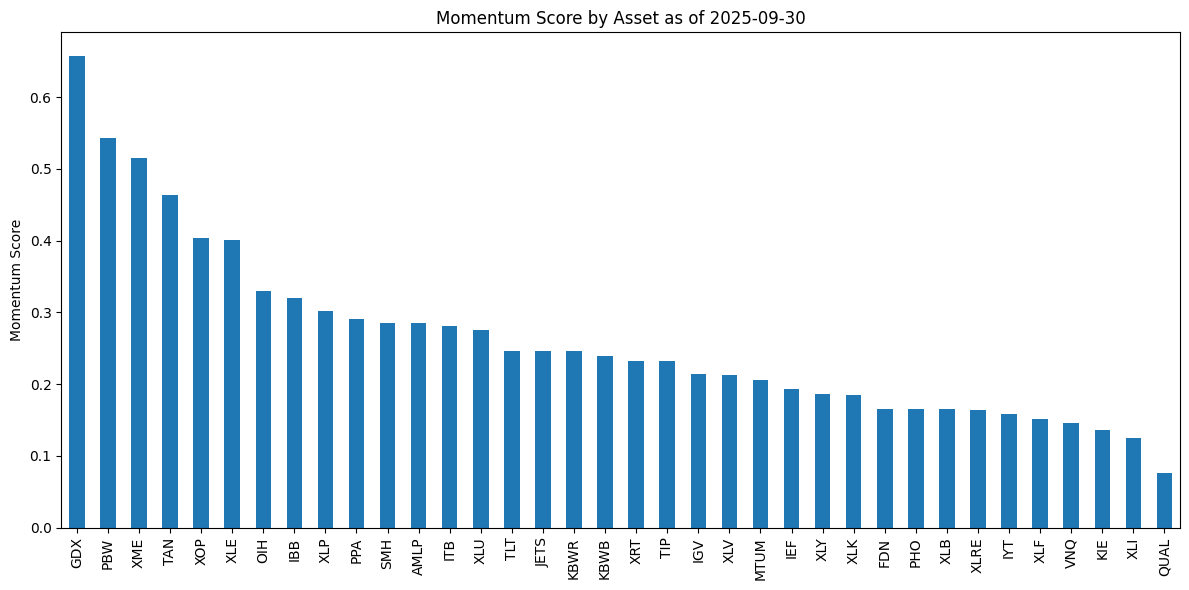

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm

# ----------------------------
# Helper Function: Fetch Data from Tiingo
# ----------------------------
def get_tiingo_data(ticker, start_date, end_date, api_key):
    """
    Fetch daily end-of-day data for a given ticker from Tiingo.
    Returns a DataFrame with the 'close' prices, indexed by date.
    """
    url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
    params = {
        'startDate': start_date.strftime('%Y-%m-%d'),
        'endDate': end_date.strftime('%Y-%m-%d'),
        'token': api_key
    }
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Error fetching data for {ticker}: {response.status_code}")
        return None
    data = response.json()
    if not data:
        print(f"No data returned for {ticker}")
        return None
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    # Use the 'close' price and rename the column to the ticker symbol.
    df = df[['close']].rename(columns={'close': ticker})
    return df

# ----------------------------
# Parameters and Tickers
# ----------------------------
TIINGO_API_KEY = "e30bc8b0b855970d930743b116e517e36b72cc8f"  # Your provided API key

# List of ETFs and assets (BTC, TLT, IEF, TIP treated like ETFs)
etfs = ["XLE", "XLF", "XLK", "XLB", "XLRE", "XLU", "XLV", "XLP",
        "XLY", "XLI", "MTUM", "QUAL", "KBWR", "KBWB", "XME",
        "VNQ", "GDX", "AMLP", "ITB", "OIH", "XRT", "FDN", "IBB",
        "SMH", "XOP", "PBW", "KIE", "PHO", "IGV", "TAN",
        "JETS", "IYT", "PPA", "BTC-USD", "TLT", "IEF", "TIP"]

# Benchmark ticker (SPY)
benchmark_ticker = "SPY"

# Define the date range: 10 years ending December 31, 2024
end_date = datetime(2025, 9, 30)
start_date = end_date - timedelta(days=365*10)

# ----------------------------
# Data Retrieval: Fetch ETF/Asset Data from Tiingo
# ----------------------------
data = {}
for etf in tqdm(etfs, desc="Fetching ETF data"):
    df = get_tiingo_data(etf, start_date, end_date, TIINGO_API_KEY)
    if df is not None:
        data[etf] = df

if not data:
    raise ValueError("No ETF data available. Please check your API key or ticker list.")

prices = pd.concat(data.values(), axis=1).ffill()

# ----------------------------
# Data Retrieval: Fetch Benchmark Data (SPY) from Tiingo
# ----------------------------
spy_data = get_tiingo_data(benchmark_ticker, start_date, end_date, TIINGO_API_KEY)
if spy_data is None:
    raise ValueError("No benchmark data available. Please check your API key or ticker.")

# ----------------------------
# Compute Monthly Data and Momentum Factors
# ----------------------------
# Use business month-end ('BM') so the last trading day is used.
monthly_prices = prices.resample('BM').last()
monthly_returns = np.log(monthly_prices).diff().dropna()

# Compute momentum factors:
# r1m: 1-month return; r3m: 3-month cumulative; r9m: 9-month cumulative
r1m = monthly_returns.copy()
r3m = monthly_returns.rolling(window=3, min_periods=3).sum()
r9m = monthly_returns.rolling(window=9, min_periods=9).sum()

# 12-month rolling volatility from monthly returns
vol = monthly_returns.rolling(window=12, min_periods=12).std()

# ----------------------------
# Compute Daily Returns for Rolling Correlation and Covariance with SPY
# ----------------------------
daily_returns = np.log(prices).diff().dropna()
daily_spy = np.log(spy_data).diff().dropna()[benchmark_ticker]

# ----------------------------
# Define Weights for Momentum Score
# ----------------------------
# 3m is weighted at 65% while 1m and 9m each get 17.5%
w1m, w3m, w9m = 0.175, 0.65, 0.175
beta, gamma = 0.3, 0.3  # Penalty for volatility and adjustment for correlation

# ----------------------------
# Select Latest Business Month-End for Output View
# ----------------------------
latest_date = monthly_prices.index[-1]

# Compute daily correlation and covariance with SPY using a 30-day window ending at latest_date.
start_corr = latest_date - pd.Timedelta(days=30)
window_daily = daily_returns.loc[start_corr:latest_date]
window_spy = daily_spy.loc[start_corr:latest_date]

corr_scores = {}
cov_scores = {}
for asset in monthly_returns.columns:
    if asset in window_daily.columns:
        corr_scores[asset] = window_daily[asset].corr(window_spy)
        cov_scores[asset] = window_daily[asset].cov(window_spy)
    else:
        corr_scores[asset] = np.nan
        cov_scores[asset] = np.nan
corr_series = pd.Series(corr_scores)
cov_series = pd.Series(cov_scores)

# Compute the momentum score at the latest_date for each asset.
momentum_score = (w1m * r1m.loc[latest_date] +
                  w3m * r3m.loc[latest_date] +
                  w9m * r9m.loc[latest_date] -
                  beta * vol.loc[latest_date] +
                  gamma * (1 - corr_series))

# Combine factors and momentum score into a DataFrame.
output_view = pd.DataFrame({
    "Return_1M": r1m.loc[latest_date],
    "Return_3M": r3m.loc[latest_date],
    "Return_9M": r9m.loc[latest_date],
    "Volatility_12M": vol.loc[latest_date],
    "Correlation_SPY_30D": corr_series,
    "Covariance_SPY_30D": cov_series,
    "Momentum_Score": momentum_score
})

print("Output View as of {} (Business Month-End):".format(latest_date.date()))
print(output_view.sort_values(by="Momentum_Score", ascending=False))

# ----------------------------
# Suggested Long/Short Composition
# ----------------------------
# Suggested Long: Top 20 assets by momentum score
# Suggested Short: Bottom 20 assets by momentum score
sorted_scores = output_view.sort_values(by="Momentum_Score", ascending=False)
suggested_long = sorted_scores.head(5).index.tolist()
suggested_short = sorted_scores.tail(5).index.tolist()

print("\nSuggested Long Assets (Top 5 by Momentum Score):")
print(suggested_long)
print("\nSuggested Short Assets (Bottom 5 by Momentum Score):")
print(suggested_short)

# Optionally, plot the momentum score for visual inspection.
plt.figure(figsize=(12, 6))
sorted_scores["Momentum_Score"].plot(kind="bar")
plt.title("Momentum Score by Asset as of {}".format(latest_date.date()))
plt.ylabel("Momentum Score")
plt.tight_layout()
plt.show()


Fetching ETF data:  92%|█████████▏| 34/37 [00:24<00:01,  1.88it/s]

Error fetching data for BTC-USD: 404


Fetching ETF data: 100%|██████████| 37/37 [00:26<00:00,  1.38it/s]
/tmp/ipython-input-3978502630.py:81: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  monthly_prices = prices.resample('BM').last()


Output View as of 2025-10-31 (Business Month-End):
      Return_1M  Return_3M  Return_9M  Volatility_12M  Correlation_SPY_30D  \
GDX   -0.058484   0.333203   0.614964        0.102193             0.019673   
TLT    0.010242   0.038039   0.028421        0.033031            -0.448431   
PBW    0.148695   0.386400   0.538869        0.101661             0.616823   
IEF    0.004035   0.020340   0.040349        0.014236            -0.422359   
XME    0.035835   0.275642   0.487866        0.088616             0.422320   
TIP    0.001438   0.015472   0.030724        0.011508            -0.210159   
TAN    0.118521   0.288768   0.373805        0.086036             0.697131   
XLP   -0.027030  -0.044862  -0.034784        0.030232            -0.099878   
IBB    0.098912   0.182748   0.139266        0.051615             0.605232   
XLV    0.035852   0.100711  -0.018000        0.042562             0.342074   
SMH    0.106457   0.228793   0.398848        0.075476             0.873906   
XLU    0.0214

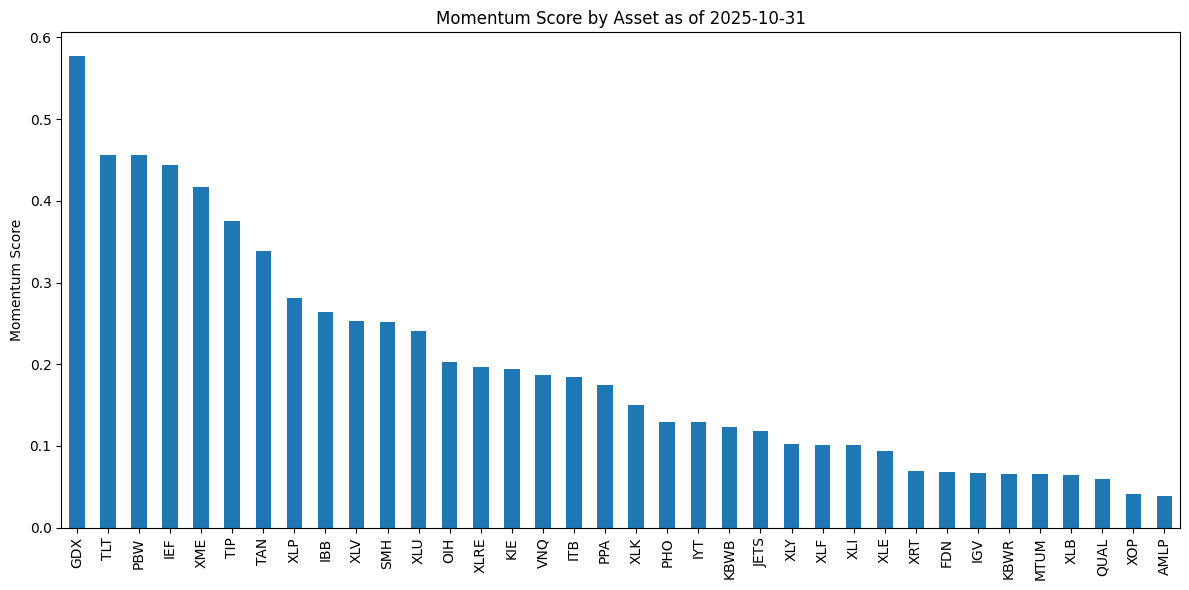

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm

# ----------------------------
# Helper Function: Fetch Data from Tiingo
# ----------------------------
def get_tiingo_data(ticker, start_date, end_date, api_key):
    """
    Fetch daily end-of-day data for a given ticker from Tiingo.
    Returns a DataFrame with the 'close' prices, indexed by date.
    """
    url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
    params = {
        'startDate': start_date.strftime('%Y-%m-%d'),
        'endDate': end_date.strftime('%Y-%m-%d'),
        'token': api_key
    }
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Error fetching data for {ticker}: {response.status_code}")
        return None
    data = response.json()
    if not data:
        print(f"No data returned for {ticker}")
        return None
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    # Use the 'close' price and rename the column to the ticker symbol.
    df = df[['close']].rename(columns={'close': ticker})
    return df

# ----------------------------
# Parameters and Tickers
# ----------------------------
TIINGO_API_KEY = "e30bc8b0b855970d930743b116e517e36b72cc8f"  # Your provided API key

# List of ETFs and assets (BTC, TLT, IEF, TIP treated like ETFs)
etfs = ["XLE", "XLF", "XLK", "XLB", "XLRE", "XLU", "XLV", "XLP",
        "XLY", "XLI", "MTUM", "QUAL", "KBWR", "KBWB", "XME",
        "VNQ", "GDX", "AMLP", "ITB", "OIH", "XRT", "FDN", "IBB",
        "SMH", "XOP", "PBW", "KIE", "PHO", "IGV", "TAN",
        "JETS", "IYT", "PPA", "BTC-USD", "TLT", "IEF", "TIP"]

# Benchmark ticker (SPY)
benchmark_ticker = "SPY"

# Define the date range: 10 years ending December 31, 2024
end_date = datetime(2025, 10, 31)
start_date = end_date - timedelta(days=365*10)

# ----------------------------
# Data Retrieval: Fetch ETF/Asset Data from Tiingo
# ----------------------------
data = {}
for etf in tqdm(etfs, desc="Fetching ETF data"):
    df = get_tiingo_data(etf, start_date, end_date, TIINGO_API_KEY)
    if df is not None:
        data[etf] = df

if not data:
    raise ValueError("No ETF data available. Please check your API key or ticker list.")

prices = pd.concat(data.values(), axis=1).ffill()

# ----------------------------
# Data Retrieval: Fetch Benchmark Data (SPY) from Tiingo
# ----------------------------
spy_data = get_tiingo_data(benchmark_ticker, start_date, end_date, TIINGO_API_KEY)
if spy_data is None:
    raise ValueError("No benchmark data available. Please check your API key or ticker.")

# ----------------------------
# Compute Monthly Data and Momentum Factors
# ----------------------------
# Use business month-end ('BM') so the last trading day is used.
monthly_prices = prices.resample('BM').last()
monthly_returns = np.log(monthly_prices).diff().dropna()

# Compute momentum factors:
# r1m: 1-month return; r3m: 3-month cumulative; r9m: 9-month cumulative
r1m = monthly_returns.copy()
r3m = monthly_returns.rolling(window=3, min_periods=3).sum()
r9m = monthly_returns.rolling(window=9, min_periods=9).sum()

# 12-month rolling volatility from monthly returns
vol = monthly_returns.rolling(window=12, min_periods=12).std()

# ----------------------------
# Compute Daily Returns for Rolling Correlation and Covariance with SPY
# ----------------------------
daily_returns = np.log(prices).diff().dropna()
daily_spy = np.log(spy_data).diff().dropna()[benchmark_ticker]

# ----------------------------
# Define Weights for Momentum Score
# ----------------------------
# 3m is weighted at 65% while 1m and 9m each get 17.5%
w1m, w3m, w9m = 0.175, 0.65, 0.175
beta, gamma = 0.3, 0.3  # Penalty for volatility and adjustment for correlation

# ----------------------------
# Select Latest Business Month-End for Output View
# ----------------------------
latest_date = monthly_prices.index[-1]

# Compute daily correlation and covariance with SPY using a 30-day window ending at latest_date.
start_corr = latest_date - pd.Timedelta(days=30)
window_daily = daily_returns.loc[start_corr:latest_date]
window_spy = daily_spy.loc[start_corr:latest_date]

corr_scores = {}
cov_scores = {}
for asset in monthly_returns.columns:
    if asset in window_daily.columns:
        corr_scores[asset] = window_daily[asset].corr(window_spy)
        cov_scores[asset] = window_daily[asset].cov(window_spy)
    else:
        corr_scores[asset] = np.nan
        cov_scores[asset] = np.nan
corr_series = pd.Series(corr_scores)
cov_series = pd.Series(cov_scores)

# Compute the momentum score at the latest_date for each asset.
momentum_score = (w1m * r1m.loc[latest_date] +
                  w3m * r3m.loc[latest_date] +
                  w9m * r9m.loc[latest_date] -
                  beta * vol.loc[latest_date] +
                  gamma * (1 - corr_series))

# Combine factors and momentum score into a DataFrame.
output_view = pd.DataFrame({
    "Return_1M": r1m.loc[latest_date],
    "Return_3M": r3m.loc[latest_date],
    "Return_9M": r9m.loc[latest_date],
    "Volatility_12M": vol.loc[latest_date],
    "Correlation_SPY_30D": corr_series,
    "Covariance_SPY_30D": cov_series,
    "Momentum_Score": momentum_score
})

print("Output View as of {} (Business Month-End):".format(latest_date.date()))
print(output_view.sort_values(by="Momentum_Score", ascending=False))

# ----------------------------
# Suggested Long/Short Composition
# ----------------------------
# Suggested Long: Top 20 assets by momentum score
# Suggested Short: Bottom 20 assets by momentum score
sorted_scores = output_view.sort_values(by="Momentum_Score", ascending=False)
suggested_long = sorted_scores.head(20).index.tolist()
suggested_short = sorted_scores.tail(20).index.tolist()

print("\nSuggested Long Assets (Top 20 by Momentum Score):")
print(suggested_long)
print("\nSuggested Short Assets (Bottom 20 by Momentum Score):")
print(suggested_short)

# Optionally, plot the momentum score for visual inspection.
plt.figure(figsize=(12, 6))
sorted_scores["Momentum_Score"].plot(kind="bar")
plt.title("Momentum Score by Asset as of {}".format(latest_date.date()))
plt.ylabel("Momentum Score")
plt.tight_layout()
plt.show()


Shortform screen

Fetching ETF data:  89%|████████▉ | 25/28 [00:07<00:00,  3.92it/s]

Error fetching data for BTC-USD: 404


Fetching ETF data: 100%|██████████| 28/28 [00:08<00:00,  3.24it/s]
/tmp/ipython-input-4242001798.py:80: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  monthly_prices = prices.resample('BM').last()


Output View as of 2025-12-31 (Business Month-End):
      Return_1M  Return_3M  Return_9M  Volatility_12M  Correlation_SPY_30D  \
GDX    0.030061   0.115687   0.623680        0.083726             0.314744   
XLP   -0.021523  -0.008843  -0.050089        0.026275            -0.292170   
XME    0.064995   0.105993   0.615461        0.054032             0.625052   
IBB   -0.029541   0.156157   0.277288        0.051662             0.496467   
OIH   -0.016853   0.091346   0.082879        0.081273             0.244443   
AMLP  -0.013519   0.001916  -0.099516        0.035891             0.008434   
XLV   -0.018243   0.106438   0.058459        0.044955             0.383530   
XOP   -0.059646  -0.045973  -0.042259        0.067012            -0.041685   
VNQ   -0.031699  -0.032575  -0.022902        0.025401             0.151727   
XLRE  -0.032190  -0.043169  -0.036500        0.023392             0.135892   
TIP   -0.012208  -0.011848  -0.010679        0.010239             0.246930   
IEF   -0.0138

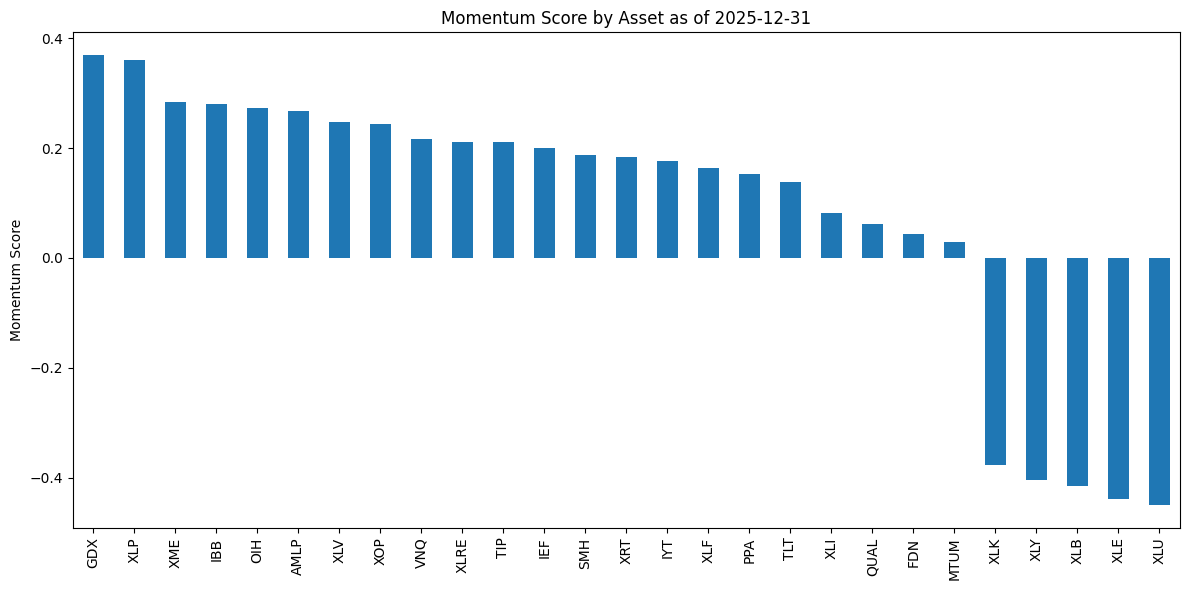

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm

# ----------------------------
# Helper Function: Fetch Data from Tiingo
# ----------------------------
def get_tiingo_data(ticker, start_date, end_date, api_key):
    """
    Fetch daily end-of-day data for a given ticker from Tiingo.
    Returns a DataFrame with the 'close' prices, indexed by date.
    """
    url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
    params = {
        'startDate': start_date.strftime('%Y-%m-%d'),
        'endDate': end_date.strftime('%Y-%m-%d'),
        'token': api_key
    }
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Error fetching data for {ticker}: {response.status_code}")
        return None
    data = response.json()
    if not data:
        print(f"No data returned for {ticker}")
        return None
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    # Use the 'close' price and rename the column to the ticker symbol.
    df = df[['close']].rename(columns={'close': ticker})
    return df

# ----------------------------
# Parameters and Tickers
# ----------------------------
TIINGO_API_KEY = "e30bc8b0b855970d930743b116e517e36b72cc8f"  # Your provided API key

# List of ETFs and assets (BTC, TLT, IEF, TIP treated like ETFs)
etfs = ["XLE", "XLF", "XLK", "XLB", "XLRE", "XLU", "XLV", "XLP",
        "XLY", "XLI", "MTUM", "QUAL", "XME",
        "VNQ", "GDX", "AMLP", "OIH", "XRT", "FDN", "IBB",
        "SMH", "XOP", "IYT", "PPA", "BTC-USD", "TLT", "IEF", "TIP"]

# Benchmark ticker (SPY)
benchmark_ticker = "SPY"

# Define the date range: 10 years ending December 31, 2024
end_date = datetime(2025, 12, 31)
start_date = end_date - timedelta(days=365*10)

# ----------------------------
# Data Retrieval: Fetch ETF/Asset Data from Tiingo
# ----------------------------
data = {}
for etf in tqdm(etfs, desc="Fetching ETF data"):
    df = get_tiingo_data(etf, start_date, end_date, TIINGO_API_KEY)
    if df is not None:
        data[etf] = df

if not data:
    raise ValueError("No ETF data available. Please check your API key or ticker list.")

prices = pd.concat(data.values(), axis=1).ffill()

# ----------------------------
# Data Retrieval: Fetch Benchmark Data (SPY) from Tiingo
# ----------------------------
spy_data = get_tiingo_data(benchmark_ticker, start_date, end_date, TIINGO_API_KEY)
if spy_data is None:
    raise ValueError("No benchmark data available. Please check your API key or ticker.")

# ----------------------------
# Compute Monthly Data and Momentum Factors
# ----------------------------
# Use business month-end ('BM') so the last trading day is used.
monthly_prices = prices.resample('BM').last()
monthly_returns = np.log(monthly_prices).diff().dropna()

# Compute momentum factors:
# r1m: 1-month return; r3m: 3-month cumulative; r9m: 9-month cumulative
r1m = monthly_returns.copy()
r3m = monthly_returns.rolling(window=3, min_periods=3).sum()
r9m = monthly_returns.rolling(window=9, min_periods=9).sum()

# 12-month rolling volatility from monthly returns
vol = monthly_returns.rolling(window=12, min_periods=12).std()

# ----------------------------
# Compute Daily Returns for Rolling Correlation and Covariance with SPY
# ----------------------------
daily_returns = np.log(prices).diff().dropna()
daily_spy = np.log(spy_data).diff().dropna()[benchmark_ticker]

# ----------------------------
# Define Weights for Momentum Score
# ----------------------------
# 3m is weighted at 65% while 1m and 9m each get 17.5%
w1m, w3m, w9m = 0.175, 0.65, 0.175
beta, gamma = 0.3, 0.3  # Penalty for volatility and adjustment for correlation

# ----------------------------
# Select Latest Business Month-End for Output View
# ----------------------------
latest_date = monthly_prices.index[-1]

# Compute daily correlation and covariance with SPY using a 30-day window ending at latest_date.
start_corr = latest_date - pd.Timedelta(days=30)
window_daily = daily_returns.loc[start_corr:latest_date]
window_spy = daily_spy.loc[start_corr:latest_date]

corr_scores = {}
cov_scores = {}
for asset in monthly_returns.columns:
    if asset in window_daily.columns:
        corr_scores[asset] = window_daily[asset].corr(window_spy)
        cov_scores[asset] = window_daily[asset].cov(window_spy)
    else:
        corr_scores[asset] = np.nan
        cov_scores[asset] = np.nan
corr_series = pd.Series(corr_scores)
cov_series = pd.Series(cov_scores)

# Compute the momentum score at the latest_date for each asset.
momentum_score = (w1m * r1m.loc[latest_date] +
                  w3m * r3m.loc[latest_date] +
                  w9m * r9m.loc[latest_date] -
                  beta * vol.loc[latest_date] +
                  gamma * (1 - corr_series))

# Combine factors and momentum score into a DataFrame.
output_view = pd.DataFrame({
    "Return_1M": r1m.loc[latest_date],
    "Return_3M": r3m.loc[latest_date],
    "Return_9M": r9m.loc[latest_date],
    "Volatility_12M": vol.loc[latest_date],
    "Correlation_SPY_30D": corr_series,
    "Covariance_SPY_30D": cov_series,
    "Momentum_Score": momentum_score
})

print("Output View as of {} (Business Month-End):".format(latest_date.date()))
print(output_view.sort_values(by="Momentum_Score", ascending=False))

# ----------------------------
# Suggested Long/Short Composition
# ----------------------------
# Suggested Long: Top 20 assets by momentum score
# Suggested Short: Bottom 20 assets by momentum score
sorted_scores = output_view.sort_values(by="Momentum_Score", ascending=False)
suggested_long = sorted_scores.head(20).index.tolist()
suggested_short = sorted_scores.tail(20).index.tolist()

print("\nSuggested Long Assets (Top 20 by Momentum Score):")
print(suggested_long)
print("\nSuggested Short Assets (Bottom 20 by Momentum Score):")
print(suggested_short)

# Optionally, plot the momentum score for visual inspection.
plt.figure(figsize=(12, 6))
sorted_scores["Momentum_Score"].plot(kind="bar")
plt.title("Momentum Score by Asset as of {}".format(latest_date.date()))
plt.ylabel("Momentum Score")
plt.tight_layout()
plt.show()


# Task
Analyze the provided asset data to identify the assets with the greatest positive change in momentum score between March and the latest business month-end, and between June and the latest business month-end. Display the top assets for each period.

## Fetch data for required months

### Subtask:
Retrieve historical data for all assets and the benchmark (SPY) for the specified date ranges (March, June, and the latest business month-end).


**Reasoning**:
I will retrieve the historical data for all assets and the benchmark from Tiingo for the specified date range.



**Reasoning**:
The previous code failed because `datetime` was not imported. I need to import `datetime` and `timedelta` from the `datetime` module. I also need to import `tqdm` and `requests`. Since I am regenerating the code, I will include all necessary imports and the helper function again to ensure the code block can be executed independently.



In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from tqdm import tqdm

# ----------------------------
# Helper Function: Fetch Data from Tiingo
# ----------------------------
def get_tiingo_data(ticker, start_date, end_date, api_key):
    """
    Fetch daily end-of-day data for a given ticker from Tiingo.
    Returns a DataFrame with the 'close' prices, indexed by date.
    """
    url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
    params = {
        'startDate': start_date.strftime('%Y-%m-%d'),
        'endDate': end_date.strftime('%Y-%m-%d'),
        'token': api_key
    }
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Error fetching data for {ticker}: {response.status_code}")
        return None
    data = response.json()
    if not data:
        print(f"No data returned for {ticker}")
        return None
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    # Use the 'close' price and rename the column to the ticker symbol.
    df = df[['close']].rename(columns={'close': ticker})
    return df

# ----------------------------
# Parameters and Tickers
# ----------------------------
TIINGO_API_KEY = "e30bc8b0b855970d930743b116e517e36b72cc8f"  # Your provided API key

# List of ETFs and assets (BTC, TLT, IEF, TIP treated like ETFs)
etfs = ["XLE", "XLF", "XLK", "XLB", "XLRE", "XLU", "XLV", "XLP",
        "XLY", "XLI", "MTUM", "QUAL", "KBWR", "KBWB", "XME",
        "VNQ", "GDX", "AMLP", "ITB", "OIH", "XRT", "FDN", "IBB",
        "SMH", "XOP", "PBW", "KIE", "PHO", "IGV", "TAN",
        "JETS", "IYT", "PPA", "BTCUSD", "TLT", "IEF", "TIP"]

# Benchmark ticker (SPY)
benchmark_ticker = "SPY"

# Define the date range dynamically based on the current date.
current_date = datetime.now()
# Find the latest business month-end before or on the current date
last_day_of_month = current_date.replace(day=1) - timedelta(days=1)
# If the last day of the month is a weekend, find the preceding Friday
if last_day_of_month.weekday() > 4:
    last_day_of_month -= timedelta(days=last_day_of_month.weekday() - 4)

end_date = last_day_of_month
start_date = end_date - timedelta(days=365*10)

# Data Retrieval: Fetch ETF/Asset Data from Tiingo
data = {}
for etf in tqdm(etfs, desc="Fetching ETF data"):
    df = get_tiingo_data(etf, start_date, end_date, TIINGO_API_KEY)
    if df is not None:
        data[etf] = df

if not data:
    raise ValueError("No ETF data available. Please check your API key or ticker list.")

prices = pd.concat(data.values(), axis=1).ffill()

# Data Retrieval: Fetch Benchmark Data (SPY) from Tiingo
spy_data = get_tiingo_data(benchmark_ticker, start_date, end_date, TIINGO_API_KEY)
if spy_data is None:
    raise ValueError("No benchmark data available. Please check your API key or ticker.")

Fetching ETF data: 100%|██████████| 37/37 [00:23<00:00,  1.60it/s]


## Calculate momentum scores for each month

### Subtask:
For each of the required months (March, June, and the latest business month-end), calculate the momentum scores for all assets using the existing logic in the notebook.


**Reasoning**:
Define a function to calculate momentum scores for a given date and then calculate the momentum scores for the required months.



**Reasoning**:
The error indicates a comparison between timezone-aware and timezone-naive timestamps. I need to ensure all timestamps are timezone-aware or timezone-naive consistently. Since the index of the `prices` DataFrame is timezone-aware, I will ensure all date calculations result in timezone-aware timestamps. I also need to handle the FutureWarning for 'BM' by using 'BME'.



**Reasoning**:
The error `TypeError: to_timestamp() got an unexpected keyword argument 'tz'` indicates that the `to_timestamp()` method from `Period` objects does not accept the `tz` argument directly. I need to create the timestamp first and then localize it to the desired timezone. I will also correct the `tz_localize` calls to `tz_convert` since the timestamps are already timezone-aware.



In [ ]:
def calculate_momentum_scores(prices_df, spy_df, end_date):
    """
    Calculates momentum scores for assets at a given end date.

    Args:
        prices_df: DataFrame of asset prices, indexed by date.
        spy_df: DataFrame of benchmark (SPY) prices, indexed by date.
        end_date: The date at which to calculate the momentum scores.

    Returns:
        A DataFrame containing the momentum scores and contributing factors.
    """
    # Ensure prices and spy_data are up to the end_date and handle timezones
    prices_subset = prices_df.loc[:end_date]
    spy_subset = spy_df.loc[:end_date]

    # Compute Monthly Data and Momentum Factors
    # Use 'BME' for Business Month End
    monthly_prices = prices_subset.resample('BME').last()
    monthly_returns = np.log(monthly_prices).diff().dropna()

    # Compute momentum factors:
    r1m = monthly_returns.copy()
    r3m = monthly_returns.rolling(window=3, min_periods=3).sum()
    r9m = monthly_returns.rolling(window=9, min_periods=9).sum()
    # Add 12-month cumulative return
    r12m = monthly_returns.rolling(window=12, min_periods=12).sum()


    # 12-month rolling volatility from monthly returns - NO LONGER USED IN SCORE
    # vol = monthly_returns.rolling(window=12, min_periods=12).std()

    # Compute Daily Returns for Rolling Correlation and Covariance with SPY - NO LONGER USED IN SCORE
    # daily_returns = np.log(prices_subset).diff().dropna()
    # daily_spy = np.log(spy_subset).diff().dropna()[benchmark_ticker]

    # Define Weights for Momentum Score
    # The weights for 1m, 3m, 9m, and 12m returns will be equal for the raw momentum score.
    # beta, gamma = 0.3, 0.3  # Penalty for volatility and adjustment for correlation - NO LONGER USED IN SCORE

    # Select the specific calculation date (which is the end_date of the monthly data subset)
    calculation_date = monthly_prices.index[-1]

    # Compute daily correlation and covariance with SPY using a 30-day window ending at calculation_date. - NO LONGER USED IN SCORE
    # start_corr = calculation_date - pd.Timedelta(days=30)
    # window_daily = daily_returns.loc[start_corr:calculation_date]
    # window_spy = daily_spy.loc[start_corr:calculation_date]

    # corr_scores = {}
    # cov_scores = {}
    # for asset in monthly_returns.columns:
    #     # Check if the asset exists in the window_daily data
    #     if asset in window_daily.columns and not window_daily[asset].isnull().all() and not window_spy.isnull().all():
    #          # Ensure there is enough data points in the window for correlation calculation
    #         if len(window_daily[asset].dropna()) > 1 and len(window_spy.dropna()) > 1:
    #             corr_scores[asset] = window_daily[asset].corr(window_spy)
    #             cov_scores[asset] = window_daily[asset].cov(window_spy)
    #         else:
    #             corr_scores[asset] = np.nan
    #             cov_scores[asset] = np.nan
    #     else:
    #         corr_scores[asset] = np.nan
    #         cov_scores[asset] = np.nan

    # corr_series = pd.Series(corr_scores)
    # cov_series = pd.Series(cov_scores)


    # Compute the raw momentum score at the calculation_date for each asset.
    # Average of 1m, 3m, 9m, and 12m returns
    momentum_score = (r1m.loc[calculation_date] +
                      r3m.loc[calculation_date] +
                      r9m.loc[calculation_date] +
                      r12m.loc[calculation_date]) / 4


    # Combine factors and momentum score into a DataFrame.
    output_view = pd.DataFrame({
        "Return_1M": r1m.loc[calculation_date],
        "Return_3M": r3m.loc[calculation_date],
        "Return_9M": r9m.loc[calculation_date],
        "Return_12M": r12m.loc[calculation_date], # Add 12-month return to output view
        # "Volatility_12M": vol.loc[calculation_date], # Removed from score, but kept for context if needed
        # "Correlation_SPY_30D": corr_series, # Removed from score
        # "Covariance_SPY_30D": cov_series, # Removed from score
        "Momentum_Score": momentum_score
    })

    return output_view


# Calculate the latest business month-end date
# User-defined end date for calculation
user_defined_end_date = datetime(2025, 11, 30) # Change this date as needed

# Find the last business day of the month for the user-defined end date
latest_month_end = user_defined_end_date.replace(day=1) + pd.offsets.BusinessMonthEnd(0)
# Ensure it's timezone-aware if prices index is timezone-aware
if prices.index.tz is not None:
    latest_month_end = latest_month_end.tz_localize(prices.index.tz)

# Define the dates for March and June of the latest year and make them timezone-aware
latest_year = latest_month_end.year
march_date = datetime(latest_year, 3, 1)
june_date = datetime(latest_year, 6, 1)

# Find the last business day of March and June and make them timezone-aware
march_month_end = march_date.replace(day=1) + pd.offsets.BusinessMonthEnd(0)
june_month_end = june_date.replace(day=1) + pd.offsets.BusinessMonthEnd(0)

if prices.index.tz is not None:
    march_month_end = march_month_end.tz_localize(prices.index.tz)
    june_month_end = june_month_end.tz_localize(prices.index.tz)


# Calculate momentum scores for each month
momentum_scores_march = calculate_momentum_scores(prices, spy_data, march_month_end)
momentum_scores_june = calculate_momentum_scores(prices, spy_data, june_month_end)
momentum_scores_latest = calculate_momentum_scores(prices, spy_data, latest_month_end)

print(f"Momentum Scores as of March {march_month_end.date()}:")
display(momentum_scores_march.sort_values(by="Momentum_Score", ascending=False))

print(f"\nMomentum Scores as of June {june_month_end.date()}:")
display(momentum_scores_june.sort_values(by="Momentum_Score", ascending=False))

print(f"\nMomentum Scores as of Latest Business Month-End {latest_month_end.date()}:")
display(momentum_scores_latest.sort_values(by="Momentum_Score", ascending=False))

Momentum Scores as of March 2025-03-31:


,Return_1M,Return_3M,Return_9M,Return_12M,Momentum_Score
GDX,0.146134,0.304279,0.303689,0.374199,0.282075
KIE,0.007629,0.068545,0.194522,0.150550,0.105311
XLU,-0.004681,0.040901,0.145983,0.183210,0.091353
XLF,-0.046484,0.030163,0.191964,0.167693,0.085834
BTCUSD,-0.021474,-0.123471,0.313530,0.166270,0.083714
PPA,-0.001372,0.015739,0.126314,0.137572,0.069563
AMLP,0.000578,0.075560,0.079305,0.090202,0.061411
KBWB,-0.103287,-0.040280,0.159796,0.156809,0.043259
XLP,-0.017117,0.038188,0.064351,0.067228,0.038162
XLRE,-0.030591,0.028601,0.085774,0.057032,0.035204



Momentum Scores as of June 2025-06-30:


,Return_1M,Return_3M,Return_9M,Return_12M,Momentum_Score
BTCUSD,0.029784,0.261169,0.526376,0.574699,0.348007
GDX,0.027458,0.124408,0.268028,0.428097,0.211998
PPA,0.060065,0.195321,0.208970,0.321635,0.196498
FDN,0.069688,0.192585,0.240153,0.273220,0.193911
KBWB,0.087646,0.131897,0.200469,0.291693,0.177926
IGV,0.054905,0.207401,0.203139,0.231167,0.174153
SMH,0.151185,0.276698,0.127688,0.067411,0.155746
MTUM,0.037219,0.173060,0.169948,0.209639,0.147467
XLK,0.092270,0.204095,0.114826,0.112746,0.130984
XME,0.111961,0.182798,0.053472,0.124856,0.118272



Momentum Scores as of Latest Business Month-End 2025-11-28:


,Return_1M,Return_3M,Return_9M,Return_12M,Momentum_Score
GDX,0.144109,0.275778,0.739753,0.793009,0.488162
PBW,-0.057106,0.224725,0.589115,0.380195,0.284232
XME,0.005163,0.164903,0.513473,0.345162,0.257175
SMH,-0.030032,0.193546,0.414375,0.374952,0.238210
TAN,-0.004284,0.163084,0.413368,0.283669,0.213959
IBB,0.086787,0.229231,0.237878,0.205425,0.189830
XLK,-0.049286,0.086700,0.238308,0.202594,0.119579
PPA,-0.042441,0.022321,0.259638,0.220322,0.114960
XLV,0.088829,0.137263,0.056901,0.067160,0.087538
XLU,0.017026,0.072166,0.134556,0.088788,0.078134


## Compare momentum scores

### Subtask:
Calculate the difference in momentum scores for each asset between March and the latest month, and between June and the latest month.


**Reasoning**:
Calculate the difference in momentum scores between the latest month and March, and between the latest month and June, and store the results in new Series.



In [ ]:
momentum_change_march_latest = momentum_scores_latest['Momentum_Score'] - momentum_scores_march['Momentum_Score']
momentum_change_june_latest = momentum_scores_latest['Momentum_Score'] - momentum_scores_june['Momentum_Score']

## Identify and display assets with greatest positive change

### Subtask:
Identify the assets with the largest positive changes in momentum scores for both periods and display them.


**Reasoning**:
Identify the top 10 assets with the largest positive changes in momentum scores for both periods and display them.



In [ ]:
# Identify the top 10 assets with the greatest positive change in momentum score (March to Latest)
top_10_march_positive_change = momentum_change_march_latest.sort_values(ascending=False).head(10)
print("Top 10 Assets with Greatest Positive Change in Momentum Score (March to Latest):")
print(top_10_march_positive_change)

# Identify the top 10 assets with the greatest negative change in momentum score (March to Latest)
top_10_march_negative_change = momentum_change_march_latest.sort_values(ascending=True).head(10)
print("\nTop 10 Assets with Greatest Negative Change in Momentum Score (March to Latest):")
print(top_10_march_negative_change)

# Identify the top 10 assets with the greatest positive change in momentum score (June to Latest)
top_10_june_positive_change = momentum_change_june_latest.sort_values(ascending=False).head(10)
print("\nTop 10 Assets with Greatest Positive Change in Momentum Score (June to Latest):")
print(top_10_june_positive_change)

# Identify the top 10 assets with the greatest negative change in momentum score (June to Latest)
top_10_june_negative_change = momentum_change_june_latest.sort_values(ascending=True).head(10)
print("\nTop 10 Assets with Greatest Negative Change in Momentum Score (June to Latest):")
print(top_10_june_negative_change)

Top 10 Assets with Greatest Positive Change in Momentum Score (March to Latest):
PBW     0.528708
TAN     0.418974
SMH     0.363906
XME     0.302736
IBB     0.250595
GDX     0.206087
XLK     0.196330
OIH     0.166302
XRT     0.154281
JETS    0.131874
Name: Momentum_Score, dtype: float64

Top 10 Assets with Greatest Negative Change in Momentum Score (March to Latest):
BTCUSD   -0.173081
AMLP     -0.101251
KIE      -0.093204
XLF      -0.069411
XLRE     -0.062297
XLP      -0.055900
VNQ      -0.047264
KBWR     -0.045928
XLE      -0.040591
TIP      -0.022749
Name: Momentum_Score, dtype: float64

Top 10 Assets with Greatest Positive Change in Momentum Score (June to Latest):
GDX    0.276165
TAN    0.267706
IBB    0.238437
PBW    0.202169
OIH    0.193017
XLV    0.156392
XME    0.138903
SMH    0.082465
ITB    0.054667
XOP    0.047227
Name: Momentum_Score, dtype: float64

Top 10 Assets with Greatest Negative Change in Momentum Score (June to Latest):
BTCUSD   -0.437374
IGV      -0.194805
FDN   

## update_momentum_score_calculation

### Subtask:
Modify the momentum score calculation to include 12-month returns and remove volatility and correlation penalties, resulting in a raw momentum score based on the average of 1m, 3m, 9m, and 12m returns.


## update_momentum_score_calculation

### Subtask:
Modify the momentum score calculation to include 12-month returns and remove volatility and correlation penalties, resulting in a raw momentum score based on the average of 1m, 3m, 9m, and 12m returns.


## Summary:

### Data Analysis Key Findings
*   The momentum score calculation has been updated to include a 12-month return component.
*   The new raw momentum score is now calculated as the equal-weighted average of 1-month, 3-month, 9-month, and 12-month cumulative returns.
*   Volatility and correlation penalties, along with their related calculations, have been removed from the momentum score formula and the `output_view` DataFrame.

### Insights or Next Steps
*   The simplified momentum score, focusing purely on various look-back returns, allows for a clearer assessment of an asset's price trend, uninfluenced by volatility or benchmark correlation.
*   The next step should involve evaluating the performance of strategies based on this revised momentum score, comparing it to previous iterations, and potentially exploring different weighting schemes for the return components if further optimization is desired.
